STATISTICAL COMPARISON – PERCENTAGES

Endoderm:
  Model 1: 8.37% ± 1.31%
  Model 2: 16.74% ± 2.19%
  p-value: 0.0027 (SIGNIFICANT)

Ectoderm:
  Model 1: 39.35% ± 4.52%
  Model 2: 35.98% ± 4.38%
  p-value: 0.5959 (not significant)

Double Positive:
  Model 1: 1.56% ± 0.77%
  Model 2: 3.39% ± 1.26%
  p-value: 0.2261 (not significant)

Other Cells:
  Model 1: 50.72% ± 4.61%
  Model 2: 43.89% ± 4.22%
  p-value: 0.2813 (not significant)

STATISTICAL COMPARISON – ABSOLUTE COUNTS

Endoderm:
  Model 1: 41.4 ± 6.9 cells
  Model 2: 118.4 ± 17.0 cells
  p-value: 0.0003 (SIGNIFICANT)

Ectoderm:
  Model 1: 181.9 ± 20.4 cells
  Model 2: 226.3 ± 22.1 cells
  p-value: 0.1476 (not significant)

Double Positive:
  Model 1: 6.2 ± 2.5 cells
  Model 2: 18.5 ± 5.7 cells
  p-value: 0.0600 (not significant)

Other Cells:
  Model 1: 258.9 ± 36.0 cells
  Model 2: 311.6 ± 38.4 cells
  p-value: 0.3235 (not significant)

Total Cells:
  Model 1: 488.3 ± 46.7
  Model 2: 674.8 ± 40.6
  p-value: 0.0047 (SIGNIFICANT)



/var/folders/ts/psqp8bvs7917l3g80plggw9m0000gp/T/ipykernel_77289/40427857.py:137: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Model', y='Total_cells', palette=['#D3D3D3', '#808080'])


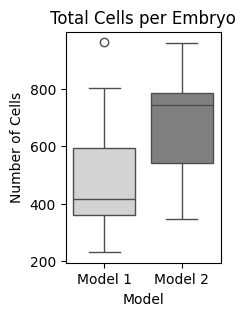

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Tue Jul 28 17:56:59 2026

@author: sdas
"""

#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

# ------------------------------
# 1. Load and prepare data
# ------------------------------
df = pd.read_csv('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4D/Fig4D_Model_1_vs_Model_2_summary_for_code.csv')

# Calculate percentages
df['Endoderm_percentage'] = (df['Endoderm_cells_count_only'] / df['Total_cells']) * 100
df['Ectoderm_percentage'] = (df['Ectoderm_cells_count_only'] / df['Total_cells']) * 100
df['Double_positive_percentage'] = (df['Double_positive_count'] / df['Total_cells']) * 100
df['Other_cells_percentage'] = (df['Negative_count'] / df['Total_cells']) * 100

# Split by model
model1 = df[df['Model'] == 'Model 1']
model2 = df[df['Model'] == 'Model 2']

# Column names for absolute counts and percentages
cell_type_cols_abs = ['Endoderm_cells_count_only', 'Ectoderm_cells_count_only',
                      'Double_positive_count', 'Negative_count']
cell_type_labels = ['Endoderm', 'Ectoderm', 'Double Positive', 'Other Cells']
cell_type_cols_pct = ['Endoderm_percentage', 'Ectoderm_percentage',
                      'Double_positive_percentage', 'Other_cells_percentage']

# ------------------------------
# 2. Statistical tests
# ------------------------------
print("=" * 80)
print("STATISTICAL COMPARISON – PERCENTAGES")
print("=" * 80)
for col, label in zip(cell_type_cols_pct, cell_type_labels):
    t_stat, p = stats.ttest_ind(model1[col], model2[col], equal_var=False)
    print(f"\n{label}:")
    print(f"  Model 1: {model1[col].mean():.2f}% ± {model1[col].sem():.2f}%")
    print(f"  Model 2: {model2[col].mean():.2f}% ± {model2[col].sem():.2f}%")
    print(f"  p-value: {p:.4f} {'(SIGNIFICANT)' if p < 0.05 else '(not significant)'}")

print("\n" + "=" * 80)
print("STATISTICAL COMPARISON – ABSOLUTE COUNTS")
print("=" * 80)
for col, label in zip(cell_type_cols_abs, cell_type_labels):
    t_stat, p = stats.ttest_ind(model1[col], model2[col], equal_var=False)
    print(f"\n{label}:")
    print(f"  Model 1: {model1[col].mean():.1f} ± {model1[col].sem():.1f} cells")
    print(f"  Model 2: {model2[col].mean():.1f} ± {model2[col].sem():.1f} cells")
    print(f"  p-value: {p:.4f} {'(SIGNIFICANT)' if p < 0.05 else '(not significant)'}")

# Also test total cells
t_stat, p = stats.ttest_ind(model1['Total_cells'], model2['Total_cells'], equal_var=False)
print(f"\nTotal Cells:")
print(f"  Model 1: {model1['Total_cells'].mean():.1f} ± {model1['Total_cells'].sem():.1f}")
print(f"  Model 2: {model2['Total_cells'].mean():.1f} ± {model2['Total_cells'].sem():.1f}")
print(f"  p-value: {p:.4f} {'(SIGNIFICANT)' if p < 0.05 else '(not significant)'}")

# After running all t-tests, collect the results
pval_results = []

# Percentages
for col, label in zip(cell_type_cols_pct, cell_type_labels):
    t_stat, p = stats.ttest_ind(model1[col], model2[col], equal_var=False)
    pval_results.append({
        'Metric': f'{label} (%)',
        't_statistic': t_stat,
        'p_value': p,
        'Significant': p < 0.05
    })

# Absolute counts
for col, label in zip(cell_type_cols_abs, cell_type_labels):
    t_stat, p = stats.ttest_ind(model1[col], model2[col], equal_var=False)
    pval_results.append({
        'Metric': f'{label} (count)',
        't_statistic': t_stat,
        'p_value': p,
        'Significant': p < 0.05
    })

# Total cells
t_stat, p = stats.ttest_ind(model1['Total_cells'], model2['Total_cells'], equal_var=False)
pval_results.append({
    'Metric': 'Total Cells',
    't_statistic': t_stat,
    'p_value': p,
    'Significant': p < 0.05
})

# Save to CSV
pval_df = pd.DataFrame(pval_results)
pval_df.to_csv('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4D/statistical_test_results.csv', index=False)
print(f"\nP-values saved to: statistical_test_results.csv")






# ------------------------------
# 3. Export summary statistics to CSV
# ------------------------------
output_data = []
for model_name, model_data in [('Model 1', model1), ('Model 2', model2)]:
    row = {'Model': model_name, 'N_embryos': len(model_data)}
    for col, label in zip(cell_type_cols_pct, cell_type_labels):
        row[f'{label}_mean_pct'] = model_data[col].mean()
        row[f'{label}_sem_pct'] = model_data[col].sem()
    for col, label in zip(cell_type_cols_abs, cell_type_labels):
        row[f'{label}_mean_count'] = model_data[col].mean()
        row[f'{label}_sem_count'] = model_data[col].sem()
    row['Total_cells_mean'] = model_data['Total_cells'].mean()
    row['Total_cells_sem'] = model_data['Total_cells'].sem()
    output_data.append(row)

output_df = pd.DataFrame(output_data)
output_filename = '/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4D/model_comparison_summary.csv'
output_df.to_csv(output_filename, index=False)
print(f"\nSummary saved to: {output_filename}")

# ------------------------------
# 4. Plot 5: Total cells per embryo (box plot)
# ------------------------------
plt.figure(figsize=(2, 3))
sns.boxplot(data=df, x='Model', y='Total_cells', palette=['#D3D3D3', '#808080'])
plt.title('Total Cells per Embryo')
plt.xlabel('Model')
plt.ylabel('Number of Cells')
plt.savefig('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4D/cell_count_total.png',
            dpi=600, bbox_inches='tight')
plt.show()


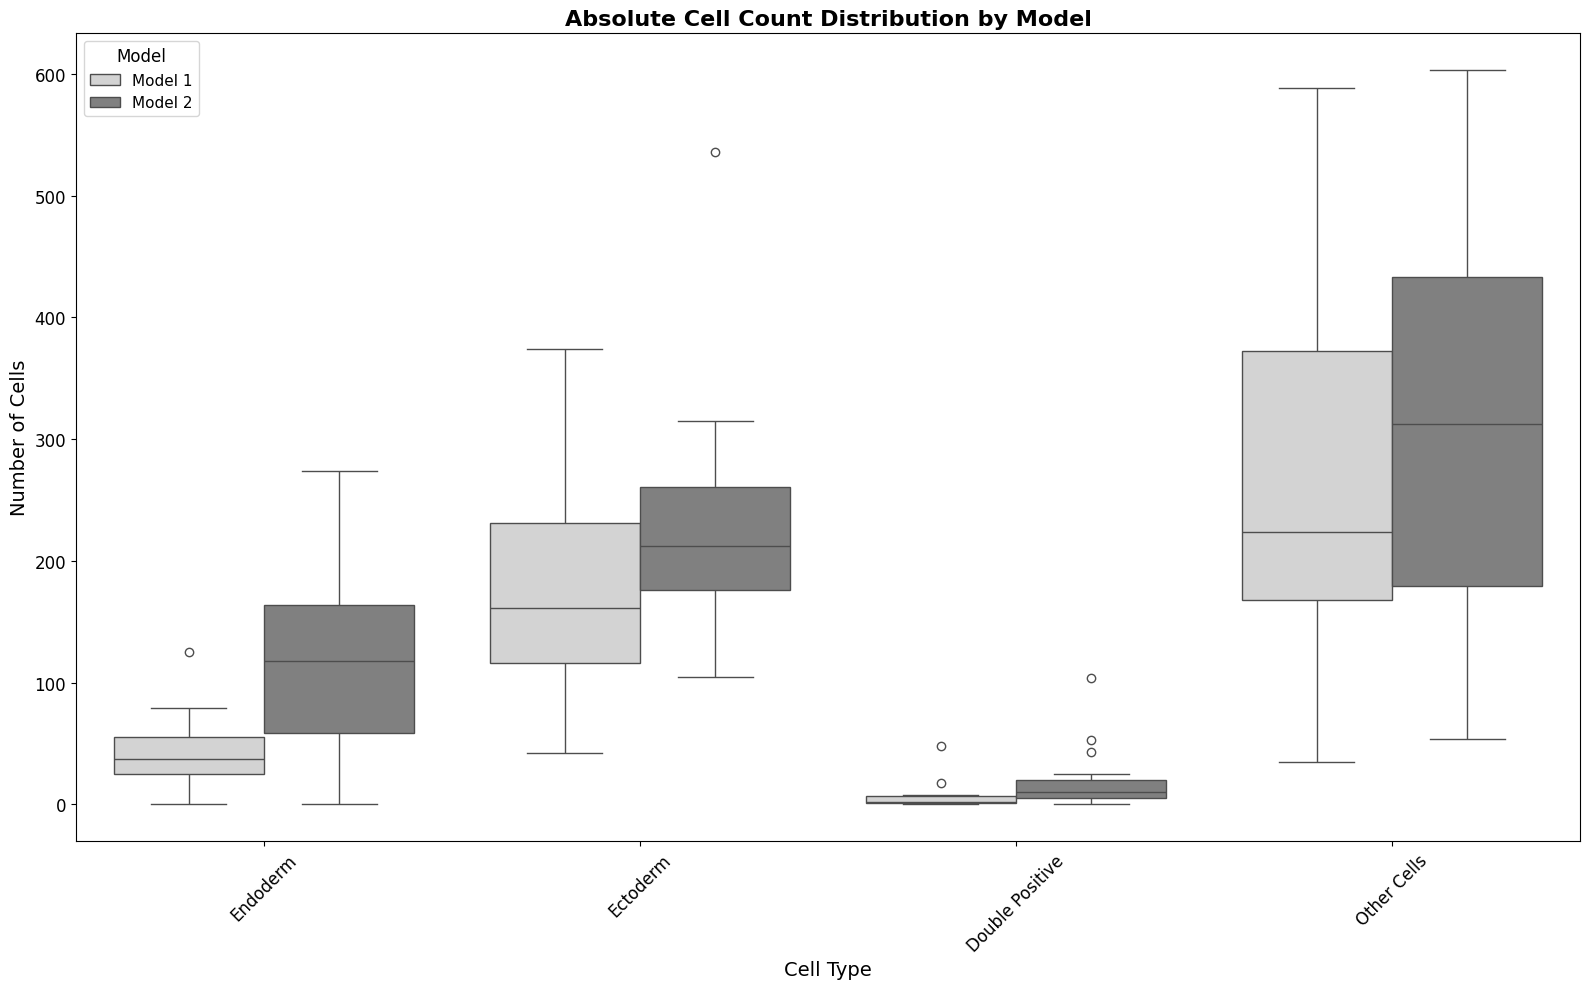

In [3]:
# ------------------------------
# 5. Plot 4: Absolute cell counts by model (box plot)
# ------------------------------
plot_data = []
for model_name, model_data in [('Model 1', model1), ('Model 2', model2)]:
    for col, label in zip(cell_type_cols_abs, cell_type_labels):
        for value in model_data[col]:
            plot_data.append({'Model': model_name, 'Cell Type': label, 'Count': value})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(16, 10))
sns.boxplot(data=plot_df, x='Cell Type', y='Count', hue='Model',
            palette=['#D3D3D3', '#808080'])
plt.title('Absolute Cell Count Distribution by Model', fontsize=16, fontweight='bold')
plt.ylabel('Number of Cells', fontsize=14)
plt.xlabel('Cell Type', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Model', title_fontsize=12, fontsize=11)
plt.tight_layout()
# Save the figure
plt.savefig('/Users/sdas/Desktop/Data/MERSCOPE/Resegmentation/19/Technical_paper/Fig_source_codes/Fig4D/absolute_cell_counts_boxplot.png',
            dpi=600, bbox_inches='tight')
plt.show()

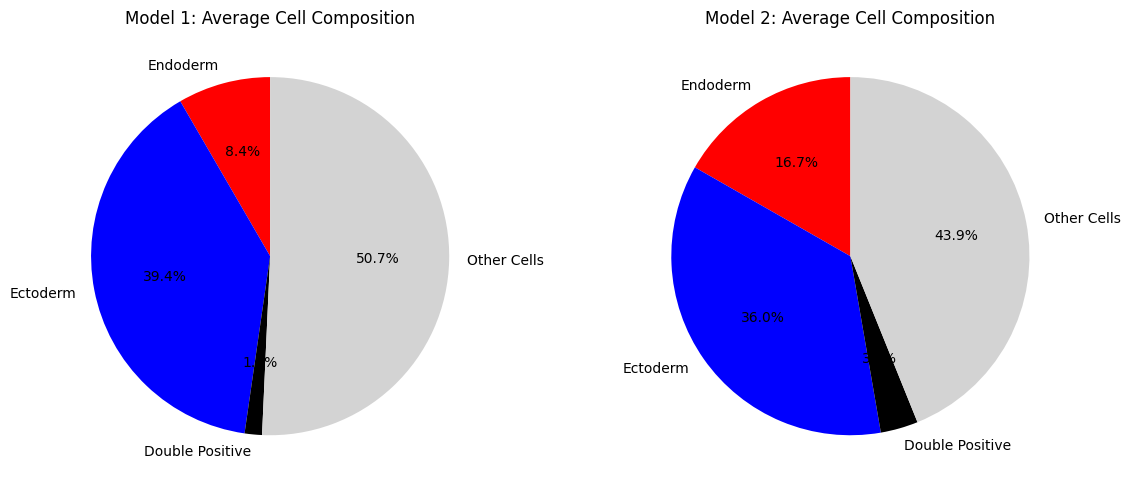

In [4]:
# ------------------------------
# 6. Side-by-side pie charts (average composition)
# ------------------------------
model1_avg_pct = model1[cell_type_cols_pct].mean()
model2_avg_pct = model2[cell_type_cols_pct].mean()

colors = ['red', 'blue', 'black', 'lightgrey']
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.pie(model1_avg_pct, labels=cell_type_labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Model 1: Average Cell Composition')

ax2.pie(model2_avg_pct, labels=cell_type_labels, colors=colors,
        autopct='%1.1f%%', startangle=90)
ax2.set_title('Model 2: Average Cell Composition')

plt.tight_layout()
plt.show()